# 🚀 Linear Regression Assignment: California Housing

Welcome to your Linear Regression assignment! In this notebook, you will apply what you've learned to a real-world dataset: predicting house prices in California.

### 🎯 Objective:
Build a regression model to predict the median house value for California districts based on various features (like median income, number of rooms, etc.).


---
## 📦 Step 0: Imports
Import the necessary libraries for data manipulation, visualization, and machine learning.

In [3]:
# TODO: Import pandas, numpy, matplotlib.pyplot, seaborn
# TODO: Import train_test_split, StandardScaler
# TODO: Import LinearRegression, metrics (mean_absolute_error, mean_squared_error, r2_score)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add your scikit-learn imports below:
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics



---
## 1️⃣ Part 1: Data Loading & Overview
We will use the California Housing dataset built into Scikit-Learn.

In [6]:
from sklearn.datasets import fetch_california_housing

# Load the dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

# TODO: Display the first 5 rows of the dataframe
df.head(5)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**💡 Hint:** 
- Use `df.info()` to check for any missing values and see the data types.
- Use `df.describe()` to get a statistical summary of the features.

Our **Target Variable** is `MedHouseVal` (Median house value in $100,000s).

In [13]:
# TODO: Check data info and basic statistics

df.info()
df.describe()
df[df["MedHouseVal"]!=100000]

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


---
## 2️⃣ Part 2: Exploratory Data Analysis (EDA)
Before training a model, it's crucial to understand the data's distribution and relationships.

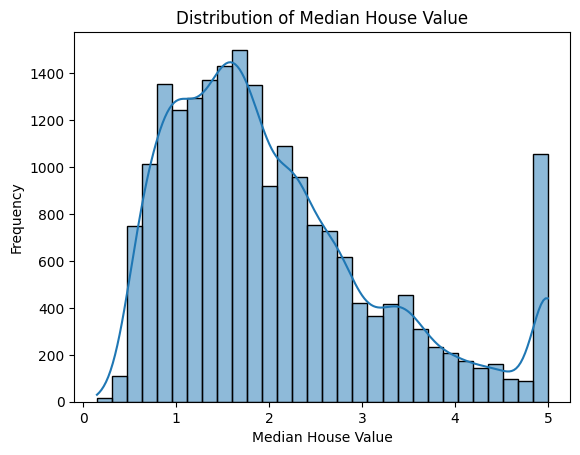

In [14]:
# TODO: Plot a histogram of the target variable (MedHouseVal)
# Hint: sns.histplot(df['MedHouseVal'], kde=True, bins=30)

sns.histplot(df['MedHouseVal'], kde=True, bins=30)
plt.title('Distribution of Median House Value')
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# TODO: Plot a correlation matrix heatmap to see which features correlate most with MedHouseVal
# Hint: plt.figure(figsize=(10, 8))
# Hint: sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')



**❓ Question:** Based on the correlation matrix, which feature has the strongest positive correlation with the house value? Which one has the strongest negative correlation?

---
## 3️⃣ Part 3: Data Preprocessing
Now, let's prepare the data for our machine learning model.

In [38]:
# 1. Separate features (X) and target (y)
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]


# TODO: 2. Split the data into Training and Testing sets (e.g., 80% train, 20% test)
# Hint: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

print(f"Testing set size: {y_train.shape[0]} samples")
print(f"Testing set size: {y_test.shape[0]} samples")


Training set size: 16512 samples
Testing set size: 4128 samples
Testing set size: 16512 samples
Testing set size: 4128 samples


**⚠️ Important:** Notice that features like `MedInc` (income) and `Population` are on completely different scales. We need to standardize them!

In [39]:
# TODO: 3. Scale the features using StandardScaler
# Hint: scaler = StandardScaler()
# Hint: X_train_scaled = scaler.fit_transform(X_train)
# Hint: X_test_scaled = scaler.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#X_train_scaled[:1] 
#X_test_scaled[:1]  

---
## 4️⃣ Part 4: Model Training
Time to train the Linear Regression model!

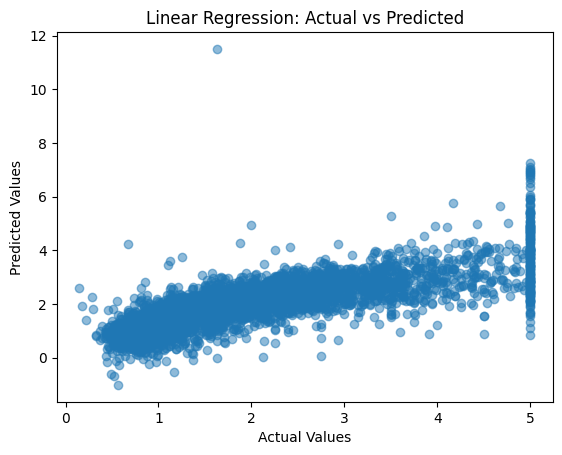

In [40]:
# TODO: Initialize and train the Linear Regression model
# Hint: lin_reg = LinearRegression()
# Hint: lin_reg.fit(X_train_scaled, y_train)


lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

pred = lin_reg.predict(X_test_scaled)

plt.scatter(y_test, pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


---
## 5️⃣ Part 5: Model Evaluation
Let's test our model on the unseen Test data and see how well it performs.

In [ ]:
# TODO: Make predictions on the scaled test set
# Hint: y_pred = lin_reg.predict(X_test_scaled)

# TODO: Calculate and print MAE, RMSE, and R2 Score
# Hint: mae = mean_absolute_error(y_test, y_pred)
#       rmse = np.sqrt(mean_squared_error(y_test, y_pred)) 
#       r2 = r2_score(y_test, y_pred)

y_pred = lin_reg.predict(X_test_scaled)

mae = metrics.mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
r2 = metrics.r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")    


Mean Absolute Error (MAE): 0.53
Root Mean Squared Error (RMSE): 0.75
R-squared (R2) Score: 0.58


---
## 🌟 Bonus / Advanced Challenge
Can you improve the error? Try using **Ridge** or **Lasso** regression to see if the R2 score goes up, or identify which features get reduced to 0 by Lasso!


In [ ]:
# Try Ridge or Lasso Regression here:

